In [8]:
import os, sys, glob
import geopandas as gpd
import pandas as pd
import xarray as xr
import rioxarray
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

atl24_flag = True

if atl24_flag:
    depth_col = 'ortho_h'
    path_to_bathy_data = "/Volumes/T7/Duck_SDB/ICESat2/atl24x.gpkg"

else:
    depth_col = 'z_ph_refr'
    path_to_bathy_data = "/Volumes/T7/Duck_SDB/ICESat2/classification_outputs/IS2_BATHY_Duck.gpkg"


path_to_validation_data = "/Volumes/T7/Duck_SDB/CUDEM/ncei_nintharcsec_dem_Job1200275/ncei_nintharcsec_dem_J1200275_clipped.tif"

bathy =  gpd.read_file(path_to_bathy_data)
crs = bathy.estimate_utm_crs()
bathy = bathy.to_crs(crs)

validation = rioxarray.open_rasterio(path_to_validation_data, masked=True, chunks=True).rio.reproject(crs)


In [9]:
# Convert to data arrays for vectorized operations
da_sample_x = xr.DataArray([p.x for p in bathy.geometry], dims='nodes')
da_sample_y = xr.DataArray([p.y for p in bathy.geometry], dims='nodes')
sampled_validation = validation.sel(x=da_sample_x, y=da_sample_y, method="nearest")

bathy['validation'] = sampled_validation.squeeze()

# drop rows with NaN values in the validation column or the depth column
bathy = bathy.dropna(subset=['validation', depth_col])

Text(0.05, 0.95, 'RMSE: 49.11 m\nR²: -32.08')

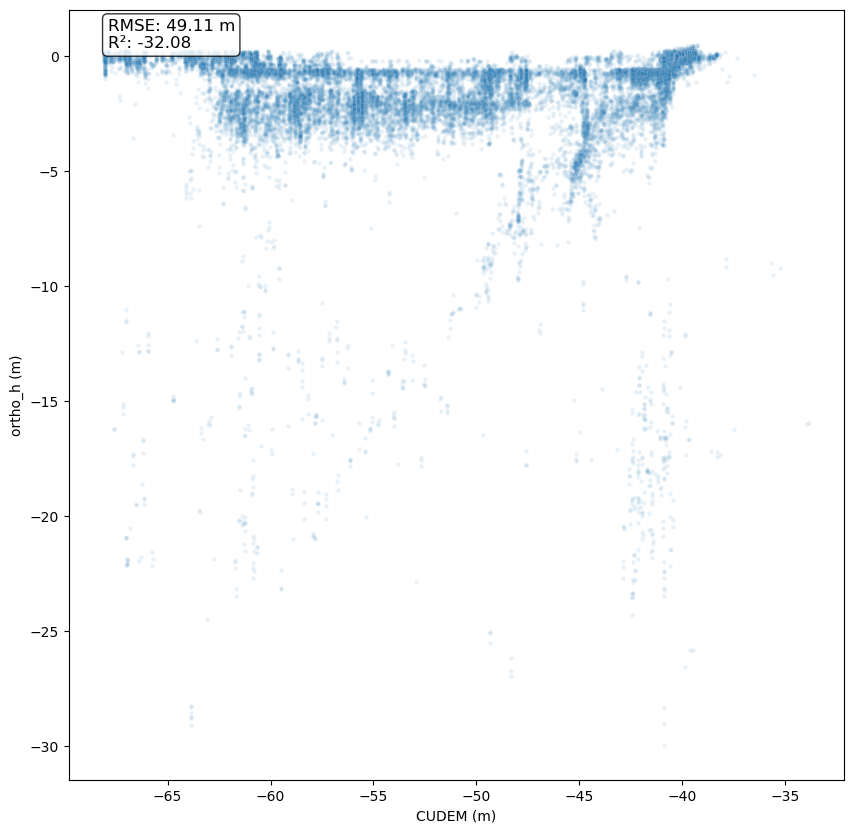

In [10]:
# scatter ortho_h vs validation

f, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=bathy, x='validation', y=depth_col, ax=ax, s=10, alpha=0.1)
ax.set_ylabel(f'{depth_col} (m)')
ax.set_xlabel('CUDEM (m)')

# compute RMSE, R2, annotate on plot
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(bathy['validation'], bathy[depth_col]))
r2 = r2_score(bathy['validation'], bathy[depth_col])
ax.annotate(f'RMSE: {rmse:.2f} m\nR²: {r2:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

